In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("climatologia_2023_2025.csv")

# convertir números con coma decimal
for c in ["tmed","prec","tmin","tmax","sol"]:
    df[c] = pd.to_numeric(df[c].str.replace(",", "."), errors="coerce")

# convertir fecha
df["fecha"] = pd.to_datetime(df["fecha"], format="%d-%m-%Y")

# crear columna mes
df["mes"] = df["fecha"].dt.month

print(df.dtypes)

fecha    datetime64[ns]
tmed            float64
prec            float64
tmin            float64
tmax            float64
sol             float64
mes               int32
dtype: object


In [2]:
df.isna().sum()

fecha    0
tmed     0
prec     0
tmin     0
tmax     0
sol      0
mes      0
dtype: int64

In [3]:
df.describe()

,fecha,tmed,prec,tmin,tmax,sol,mes
count,1096,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,2024-07-01 12:00:00,19.793522,1.148631,15.512226,24.074088,7.963869,6.521898
min,2023-01-01 00:00:00,6.800000,0.000000,1.900000,10.300000,0.000000,1.000000
25%,2023-10-01 18:00:00,15.100000,0.000000,10.500000,19.600000,5.950000,4.000000
50%,2024-07-01 12:00:00,19.600000,0.000000,15.300000,24.000000,8.600000,7.000000
75%,2025-04-01 06:00:00,24.800000,0.000000,20.800000,28.800000,10.800000,10.000000
max,2025-12-31 00:00:00,34.800000,96.800000,27.500000,44.500000,13.500000,12.000000
std,NaN,5.686520,5.729497,6.096537,5.611984,3.548918,3.450561


In [4]:
df[df["sol"] == df["sol"].min()]

,fecha,tmed,prec,tmin,tmax,sol,mes
62,2025-09-29,18.9,96.8,17.8,20.0,0.0,9
66,2025-12-16,10.6,40.4,8.7,12.5,0.0,12
68,2025-03-18,11.4,31.2,9.8,12.9,0.0,3
69,2023-02-08,9.2,30.2,7.8,10.6,0.0,2
72,2024-10-27,14.9,23.0,12.8,17.0,0.0,10
75,2025-12-14,12.7,21.5,12.2,13.2,0.0,12
87,2023-05-23,19.2,14.2,17.7,20.7,0.0,5
90,2024-09-21,20.6,13.6,18.8,22.5,0.0,9
92,2025-10-13,19.8,13.0,18.5,21.0,0.0,10
99,2024-04-29,15.2,9.3,13.8,16.6,0.0,4


In [5]:
# 1. Temperatura máxima menor que mínima
df[df["tmax"] < df["tmin"]]

,fecha,tmed,prec,tmin,tmax,sol,mes


In [6]:
df[(df["tmed"] < df["tmin"]) | (df["tmed"] > df["tmax"])]

,fecha,tmed,prec,tmin,tmax,sol,mes


In [7]:
df[df["prec"] < 0]

,fecha,tmed,prec,tmin,tmax,sol,mes


In [8]:
df[(df["sol"] < 0) | (df["sol"] > 24)]

,fecha,tmed,prec,tmin,tmax,sol,mes


DATOS PARA CADA VARIABLE

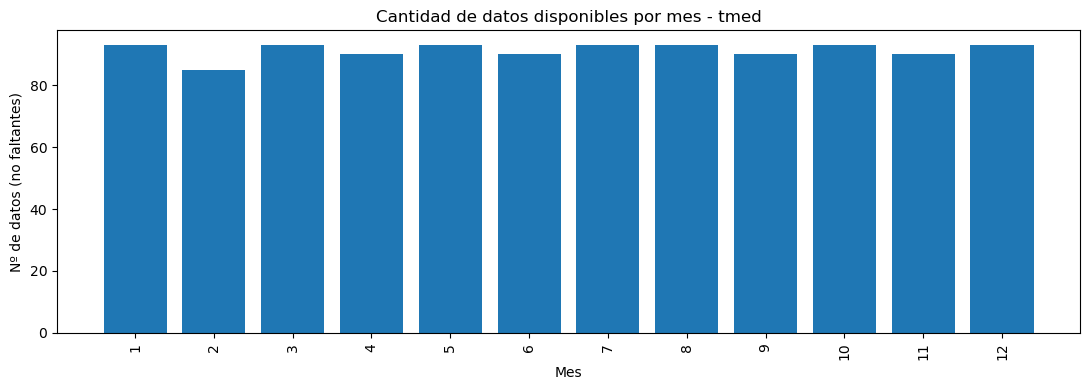

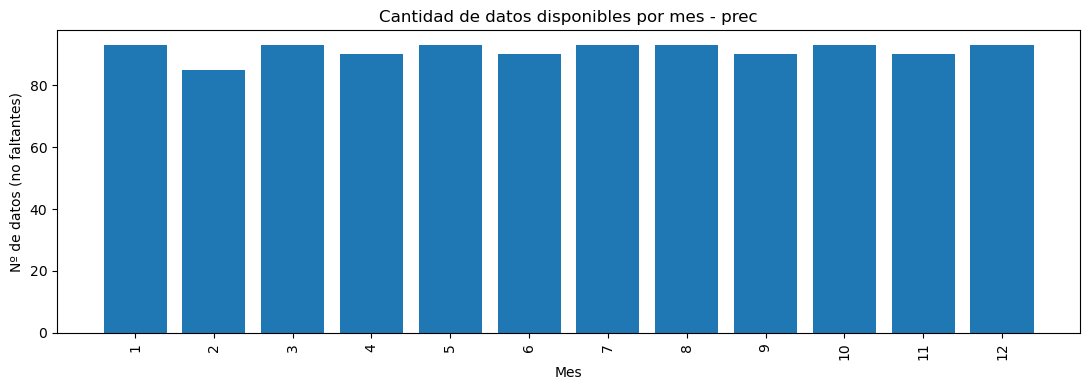

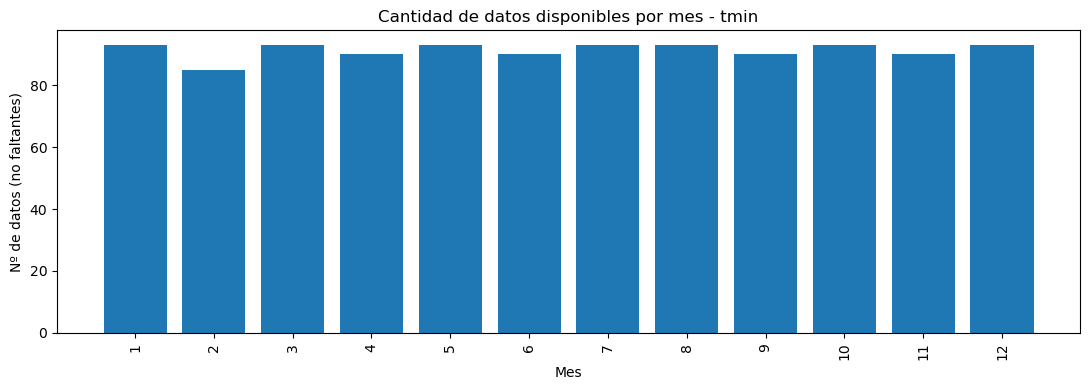

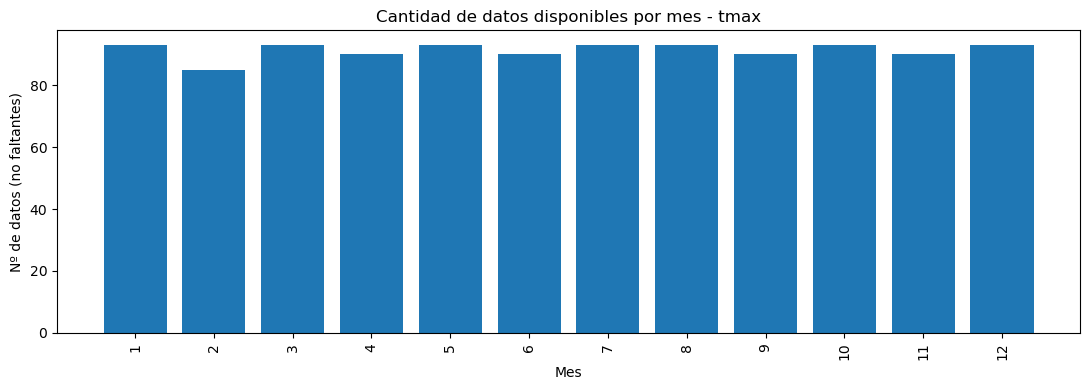

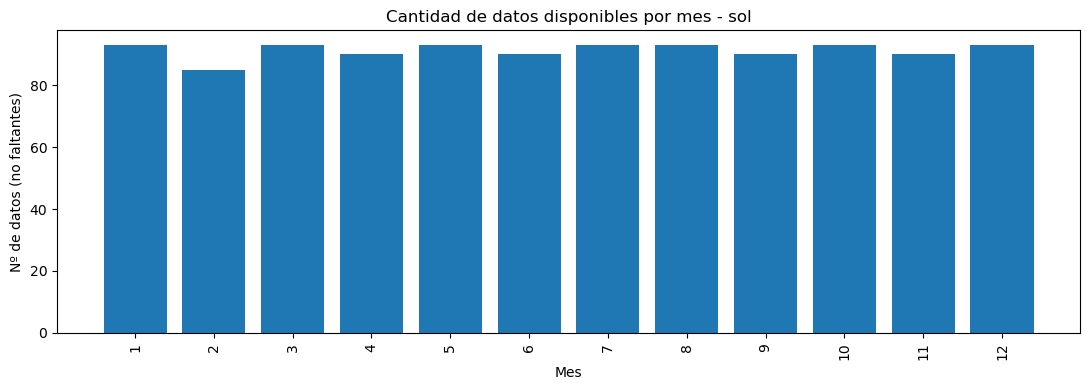

In [9]:
def plot_conteo_por_mes(df, col):
    conteo = df.groupby("mes")[col].apply(lambda s: s.notna().sum()).sort_index()

    plt.figure(figsize=(11, 4))
    plt.bar(conteo.index.astype(str), conteo.values)
    plt.title(f"Cantidad de datos disponibles por mes - {col}")
    plt.xlabel("Mes")
    plt.ylabel("Nº de datos (no faltantes)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

vars_clima = ["tmed", "prec", "tmin", "tmax", "sol"]

for col in vars_clima:
    plot_conteo_por_mes(df, col)

TMED

count    1096.000000
mean       19.793522
std         5.686520
min         6.800000
1%          9.000000
5%         11.200000
25%        15.100000
50%        19.600000
75%        24.800000
95%        28.400000
99%        30.305000
max        34.800000
Name: tmed, dtype: float64
0


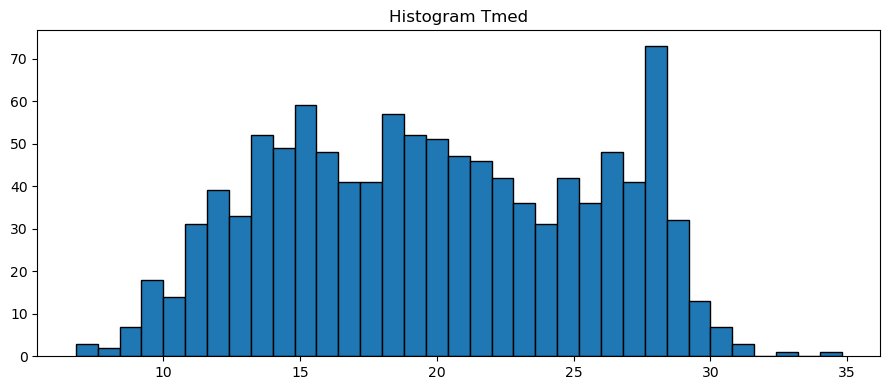

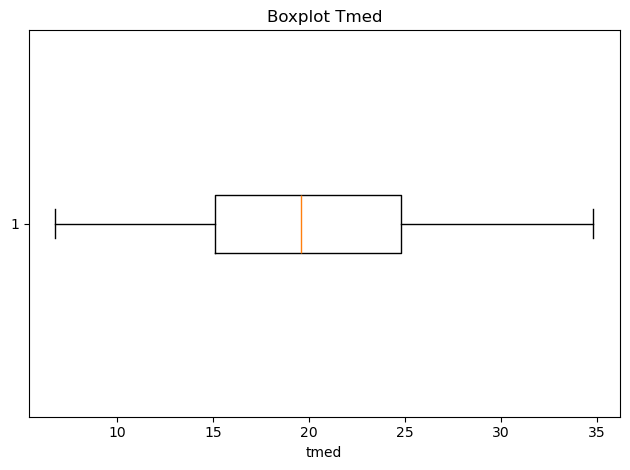

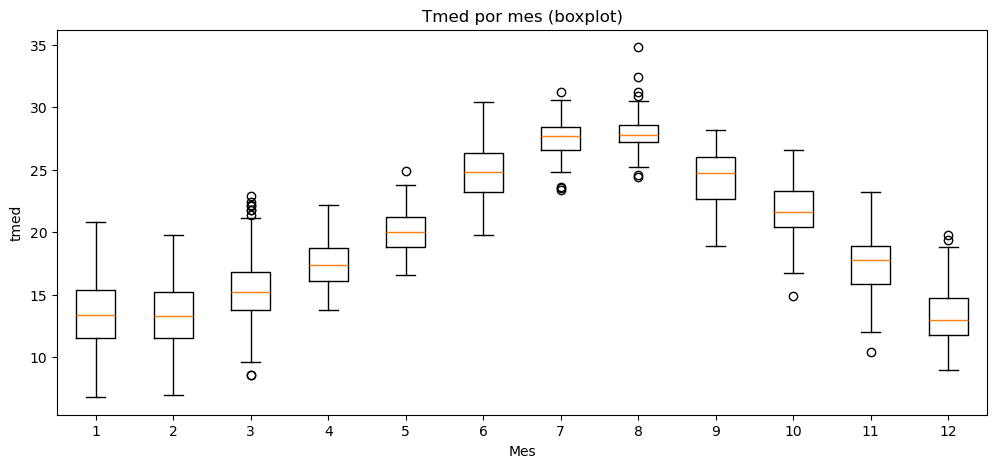

,fecha,tmed,tmin,tmax
429,2023-08-10,34.8,25.0,44.5
992,2025-08-11,32.4,26.5,38.2
998,2025-08-17,31.2,25.8,36.6
975,2025-07-20,31.2,23.8,38.7
997,2025-08-16,30.9,24.8,37.0
413,2023-07-24,30.6,26.2,35.1
442,2023-08-23,30.5,24.2,36.8
422,2023-08-02,30.4,25.2,35.6
443,2023-08-24,30.4,24.5,36.4
55,2025-08-28,30.4,25.2,35.6


In [10]:
print(df["tmed"].describe(percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

faltantes = df["tmed"].isna().sum()
print(faltantes)

#Histograma´
plt.figure(figsize=(9,4))
plt.hist(df["tmed"].dropna(), bins = 35, edgecolor = "black")
plt.title("Histogram Tmed")
plt.tight_layout()
plt.show()

# Boxplot (Atipicos)
plt.boxplot(df["tmed"].dropna().values, vert = False, showfliers=True)
plt.title("Boxplot Tmed")
plt.xlabel("tmed")
plt.tight_layout()
plt.show()

#Boxplot por mes
tmp = df[["mes", "tmed"]].dropna()
data = [tmp.loc[tmp["mes"] == m, "tmed"].values for m in range(1, 13)]
if any(len(a) for a in data):
    plt.figure(figsize=(12,5))
    plt.boxplot(data, tick_labels=[str(m) for m in range(1,13)])
    plt.title(f"Tmed por mes (boxplot)")
    plt.xlabel("Mes"); plt.ylabel("tmed")
    plt.show()

df.sort_values("tmed", ascending=False)[["fecha","tmed", "tmin", "tmax"]].head(10)

In [ ]:
import pandas as pd

outliers_por_mes = []

for m in range(1, 13):
    datos_mes = df.loc[df["mes"] == m, ["fecha", "tmed", "tmin", "tmax"]].dropna()

    if len(datos_mes) == 0:
        continue

    Q1 = datos_mes["tmed"].quantile(0.25)
    Q3 = datos_mes["tmed"].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = datos_mes[(datos_mes["tmed"] < lim_inf) | (datos_mes["tmed"] > lim_sup)]
    outliers["mes"] = m

    outliers_por_mes.append(outliers)

outliers_df = pd.concat(outliers_por_mes)

print(outliers_df.sort_values(["mes", "tmed"]))

          fecha  tmed  tmin  tmax  mes
303  2023-03-01   8.6   4.7  12.6    3
304  2023-03-02   8.6   4.0  13.2    3
314  2023-03-13  21.4  13.3  29.5    3
311  2023-03-10  21.8  16.5  27.2    3
327  2023-03-26  21.8  13.4  30.1    3
312  2023-03-11  22.1  17.2  27.0    3
310  2023-03-09  22.2  18.0  26.4    3
332  2023-03-31  22.4  15.8  29.0    3
313  2023-03-12  22.9  16.6  29.2    3
50   2025-05-31  24.9  20.7  29.1    5
695  2024-07-02  23.4  19.6  27.2    7
246  2025-07-25  23.5  19.2  27.8    7
79   2024-07-01  23.6  19.2  28.1    7
975  2025-07-20  31.2  23.8  38.7    7
448  2023-08-30  24.4  20.4  28.4    8
449  2023-08-31  24.6  20.2  28.9    8
997  2025-08-16  30.9  24.8  37.0    8
998  2025-08-17  31.2  25.8  36.6    8
992  2025-08-11  32.4  26.5  38.2    8
429  2023-08-10  34.8  25.0  44.5    8
72   2024-10-27  14.9  12.8  17.0   10
1071 2025-11-21  10.4   7.0  13.9   11
534  2023-12-12  19.4  13.4  25.5   12
533  2023-12-11  19.8  12.2  27.3   12


C:\Users\vicen\AppData\Local\Temp\ipykernel_20396\2039004051.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["mes"] = m
C:\Users\vicen\AppData\Local\Temp\ipykernel_20396\2039004051.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["mes"] = m
C:\Users\vicen\AppData\Local\Temp\ipykernel_20396\2039004051.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

TMAX

count    1096.000000
mean       24.074088
std         5.611984
min        10.300000
1%         12.595000
5%         15.000000
25%        19.600000
50%        24.000000
75%        28.800000
95%        32.400000
99%        35.600000
max        44.500000
Name: tmax, dtype: float64
0


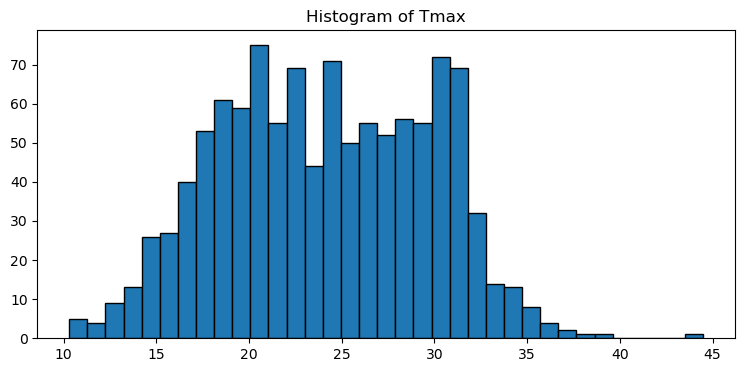

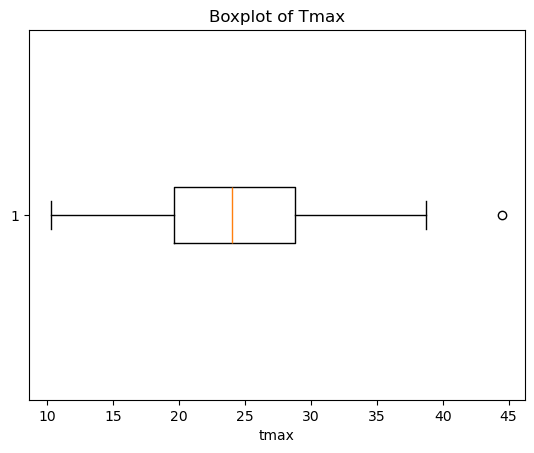

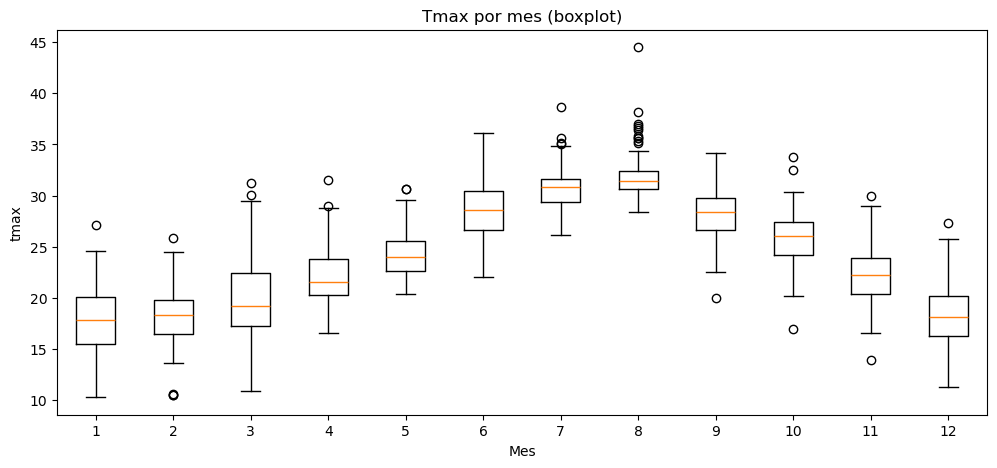

,fecha,tmax,tmin,tmed
429,2023-08-10,44.5,25.0,34.8
975,2025-07-20,38.7,23.8,31.2
992,2025-08-11,38.2,26.5,32.4
997,2025-08-16,37.0,24.8,30.9
442,2023-08-23,36.8,24.2,30.5
998,2025-08-17,36.6,25.8,31.2
443,2023-08-24,36.4,24.5,30.4
958,2025-06-30,36.1,24.8,30.4
996,2025-08-15,35.8,23.3,29.6
55,2025-08-28,35.6,25.2,30.4


In [11]:
print(df["tmax"].describe(percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

faltantes = df["tmax"].isna().sum()
print(faltantes)

plt.figure(figsize=(9,4))
plt.hist(df["tmax"].dropna().values, bins = 35, edgecolor = "black")
plt.title("Histogram of Tmax")
plt.show()

plt.boxplot(df["tmax"], vert = False, showfliers=True)
plt.title("Boxplot of Tmax")
plt.xlabel("tmax")
plt.show()

tmp = df[["mes", "tmax"]].dropna()
data = [tmp.loc[tmp["mes"] == m, "tmax"].values for m in range(1, 13)]
if any(len(a) for a in data):
    plt.figure(figsize=(12,5))
    plt.boxplot(data, tick_labels=[str(m) for m in range(1,13)])
    plt.title(f"Tmax por mes (boxplot)")
    plt.xlabel("Mes"); plt.ylabel("tmax")
    plt.show()

df.sort_values("tmax", ascending=False)[["fecha","tmax", "tmin", "tmed"]].head(10)

In [12]:
outliers_por_mes = []

for m in range(1, 13):
    datos_mes = df.loc[df["mes"] == m, ["fecha","tmax","tmin","tmed"]].dropna()

    if len(datos_mes) == 0:
        continue

    Q1 = datos_mes["tmax"].quantile(0.25)
    Q3 = datos_mes["tmax"].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = datos_mes[(datos_mes["tmax"] < lim_inf) | (datos_mes["tmax"] > lim_sup)]
    outliers["mes"] = m

    outliers_por_mes.append(outliers)

outliers_mes_df = pd.concat(outliers_por_mes)

print(outliers_mes_df.sort_values(["mes","tmax"]))

          fecha  tmax  tmin  tmed  mes
853  2025-01-27  27.1  14.4  20.8    1
2    2023-02-27  10.5   3.5   7.0    2
131  2023-02-06  10.5   5.9   8.2    2
69   2023-02-08  10.6   7.8   9.2    2
590  2024-02-13  25.9  13.6  19.8    2
327  2023-03-26  30.1  13.4  21.8    3
331  2023-03-30  31.2  11.0  21.1    3
347  2023-04-15  29.0  13.8  21.4    4
344  2023-04-12  31.5  12.8  22.2    4
651  2024-05-04  30.6  13.5  22.0    5
920  2025-05-19  30.6  16.3  23.4    5
959  2025-07-01  35.0  24.2  29.6    7
413  2023-07-24  35.1  26.2  30.6    7
960  2025-07-02  35.6  25.0  30.3    7
975  2025-07-20  38.7  23.8  31.2    7
1008 2025-08-29  35.1  23.2  29.2    8
441  2023-08-22  35.3  24.0  29.6    8
55   2025-08-28  35.6  25.2  30.4    8
422  2023-08-02  35.6  25.2  30.4    8
996  2025-08-15  35.8  23.3  29.6    8
443  2023-08-24  36.4  24.5  30.4    8
998  2025-08-17  36.6  25.8  31.2    8
442  2023-08-23  36.8  24.2  30.5    8
997  2025-08-16  37.0  24.8  30.9    8
992  2025-08-11  38.2  26

C:\Users\vicen\AppData\Local\Temp\ipykernel_13416\1373983874.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["mes"] = m
C:\Users\vicen\AppData\Local\Temp\ipykernel_13416\1373983874.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["mes"] = m
C:\Users\vicen\AppData\Local\Temp\ipykernel_13416\1373983874.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

TMIN

count    1096.000000
mean       15.512226
std         6.096537
min         1.900000
1%          4.000000
5%          5.800000
25%        10.500000
50%        15.300000
75%        20.800000
95%        25.000000
99%        26.105000
max        27.500000
Name: tmin, dtype: float64
0


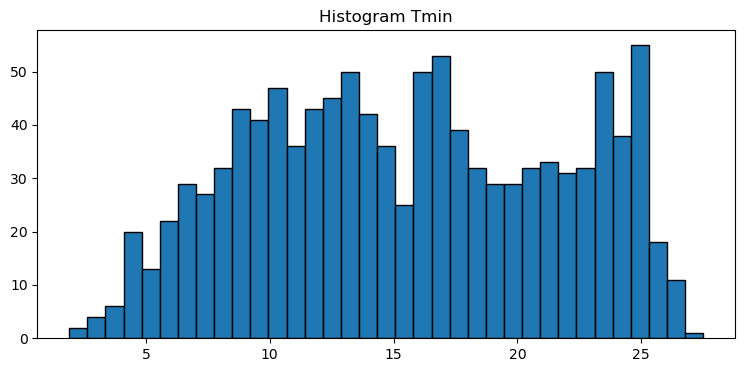

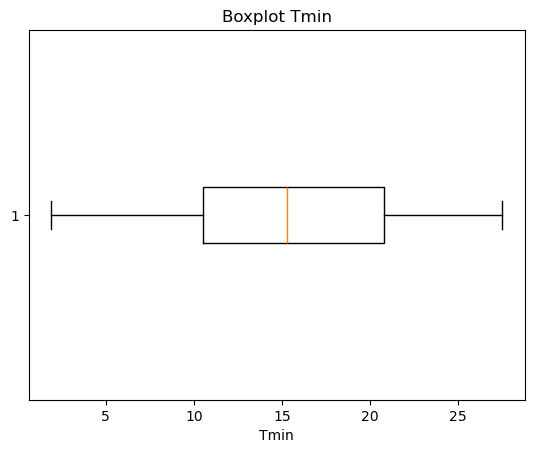

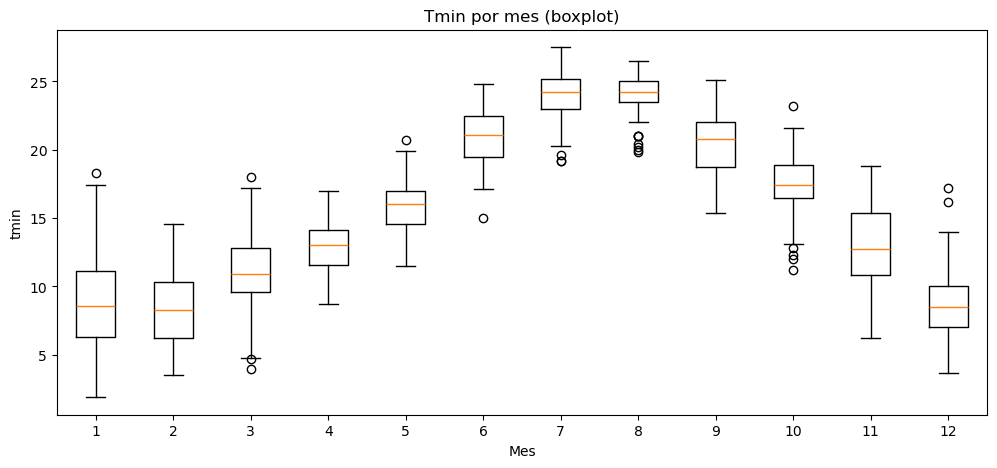

,fecha,tmin,tmax,tmed
279,2023-01-31,1.9,16.0,9.0
272,2023-01-23,2.3,12.8,7.6
845,2025-01-15,2.8,16.2,9.5
276,2023-01-27,2.8,14.4,8.6
273,2023-01-24,3.2,11.8,7.5
1,2023-01-29,3.2,10.3,6.8
2,2023-02-27,3.5,10.5,7.0
550,2023-12-28,3.7,14.8,9.2
304,2023-03-02,4.0,13.2,8.6
302,2023-02-28,4.0,17.8,10.9


In [13]:
print(df["tmin"].describe(percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

faltantes = df["tmin"].isna().sum()
print(faltantes)

plt.figure(figsize=(9,4))
plt.hist(df["tmin"].dropna(), bins = 35, edgecolor = "black")
plt.title("Histogram Tmin")
plt.show()

plt.boxplot(df["tmin"].dropna(), vert = False, showfliers=True)
plt.title("Boxplot Tmin")
plt.xlabel("Tmin")
plt.show()

tmp = df[["mes", "tmin"]].dropna()
data = [tmp.loc[tmp["mes"] == m, "tmin"].values for m in range(1, 13)]
if any(len(a) for a in data):
    plt.figure(figsize=(12,5))
    plt.boxplot(data, tick_labels=[str(m) for m in range(1,13)])
    plt.title(f"Tmin por mes (boxplot)")
    plt.xlabel("Mes"); plt.ylabel("tmin")
    plt.show()

df.sort_values("tmin", ascending=True)[["fecha","tmin", "tmax", "tmed"]].head(10)

In [15]:
outliers_tmin_mes = []

for m in range(1, 13):
    datos_mes = df.loc[df["mes"] == m, ["fecha", "mes", "tmin", "tmax", "tmed"]].dropna()

    if len(datos_mes) == 0:
        continue

    Q1 = datos_mes["tmin"].quantile(0.25)
    Q3 = datos_mes["tmin"].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = datos_mes[
        (datos_mes["tmin"] < lim_inf) |
        (datos_mes["tmin"] > lim_sup)
    ].copy()

    outliers_tmin_mes.append(outliers)

outliers_tmin_mes_df = pd.concat(outliers_tmin_mes)

outliers_tmin_mes_df.sort_values(["mes", "tmin"])[
    ["fecha", "mes", "tmin", "tmax", "tmed"]
]

,fecha,mes,tmin,tmax,tmed
19,2024-01-16,1,18.3,22.5,20.4
304,2023-03-02,3,4.0,13.2,8.6
303,2023-03-01,3,4.7,12.6,8.6
310,2023-03-09,3,18.0,26.4,22.2
50,2025-05-31,5,20.7,29.1,24.9
681,2024-06-13,6,15.0,24.7,19.8
79,2024-07-01,7,19.2,28.1,23.6
246,2025-07-25,7,19.2,27.8,23.5
695,2024-07-02,7,19.6,27.2,23.4
446,2023-08-28,8,19.8,34.0,26.9


SOL

count    1096.000000
mean        7.963869
std         3.548918
min         0.000000
1%          0.000000
5%          0.600000
25%         5.950000
50%         8.600000
75%        10.800000
95%        12.800000
99%        13.205000
max        13.500000
Name: sol, dtype: float64
0


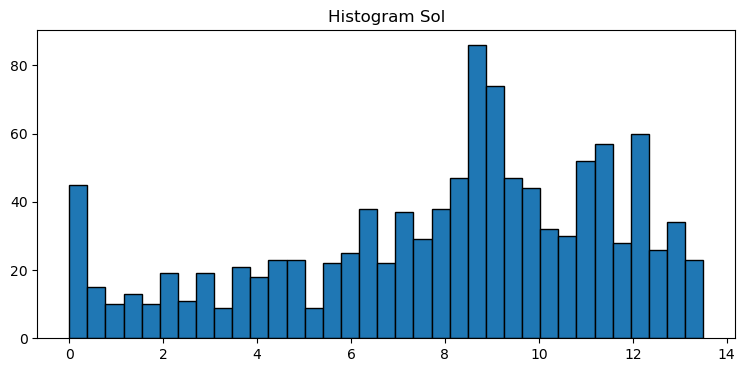

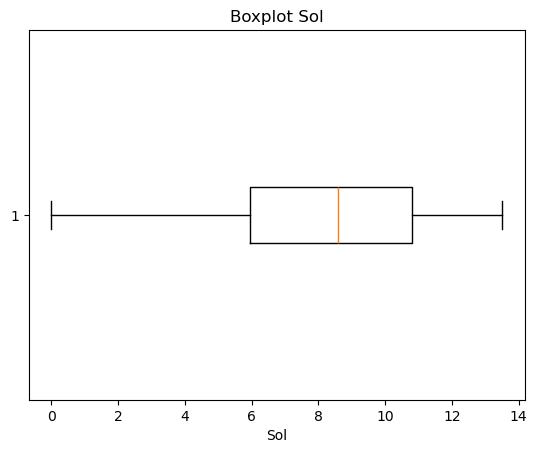

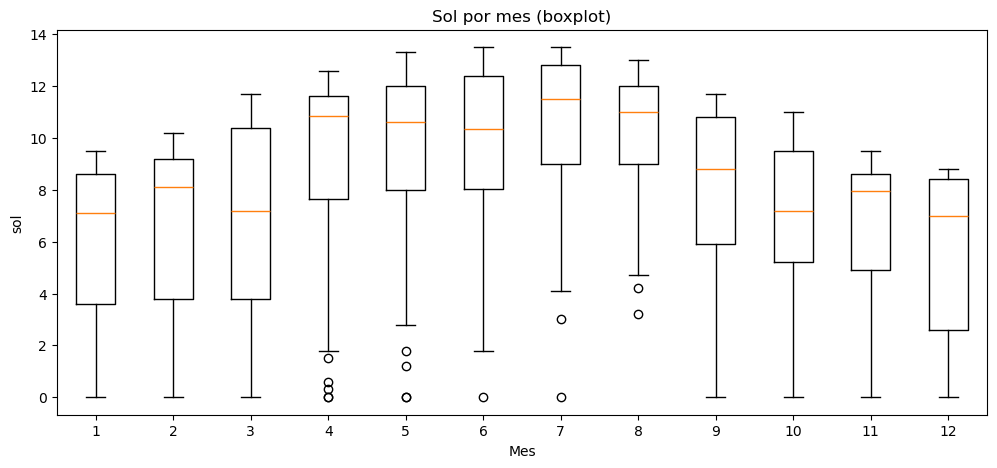

,fecha,sol,prec
384,2023-06-15,13.5,0.0
689,2024-06-21,13.5,0.0
389,2023-06-23,13.5,0.0
388,2023-06-22,13.5,0.0
696,2024-07-03,13.5,0.0
697,2024-07-04,13.4,0.0
390,2023-06-24,13.4,0.0
655,2024-05-08,13.3,0.0
930,2025-05-29,13.3,0.0
926,2025-05-25,13.3,0.0


In [27]:
print(df["sol"].describe(percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

faltantes = df["sol"].isna().sum()
print(faltantes)

plt.figure(figsize=(9,4))
plt.hist(df["sol"].dropna().values, bins = 35, edgecolor = "black")
plt.title("Histogram Sol")
plt.show()

plt.boxplot(df["sol"].dropna().values, vert = False, showfliers=True)
plt.title("Boxplot Sol")
plt.xlabel("Sol")
plt.show()

tmp = df[["mes", "sol"]].dropna()
data = [tmp.loc[tmp["mes"] == m, "sol"].values for m in range(1, 13)]
if any(len(a) for a in data):
    plt.figure(figsize=(12,5))
    plt.boxplot(data, tick_labels=[str(m) for m in range(1,13)])
    plt.title(f"Sol por mes (boxplot)")
    plt.xlabel("Mes"); plt.ylabel("sol")
    plt.show()

df.sort_values("sol", ascending=False)[["fecha","sol", "prec"]].head(10)

In [19]:
outliers_sol_mes = []

for m in range(1, 13):
    datos_mes = df.loc[df["mes"] == m, ["fecha", "mes", "sol", "prec"]].dropna()

    if len(datos_mes) == 0:
        continue

    Q1 = datos_mes["sol"].quantile(0.25)
    Q3 = datos_mes["sol"].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = datos_mes[
        (datos_mes["sol"] < lim_inf) |
        (datos_mes["sol"] > lim_sup)
    ].copy()

    outliers_sol_mes.append(outliers)

outliers_sol_mes_df = pd.concat(outliers_sol_mes)

outliers_sol_mes_df.sort_values(["mes", "sol"])[
    ["fecha", "mes", "sol", "prec"]
]

,fecha,mes,sol,prec
99,2024-04-29,4,0.0,9.3
176,2025-04-03,4,0.0,1.2
630,2024-04-07,4,0.3,0.0
893,2025-04-12,4,0.6,0.0
190,2025-04-11,4,1.5,0.8
87,2023-05-23,5,0.0,14.2
908,2025-05-02,5,0.0,0.0
215,2025-05-07,5,1.2,0.3
154,2023-05-25,5,1.8,2.2
220,2023-06-07,6,0.0,0.2


PRECIPITATION

count    1096.000000
mean        1.148631
std         5.729497
min         0.000000
1%          0.000000
5%          0.000000
25%         0.000000
50%         0.000000
75%         0.000000
95%         5.800000
99%        22.145000
max        96.800000
Name: prec, dtype: float64
Número de días sin precipitación: 906
Número de días con precipitación: 190
prec_intervalo
0 mm         906
0-5 mm       132
5-10 mm       22
10-20 mm      17
20-50 mm      15
50-100 mm      4
Name: count, dtype: int64


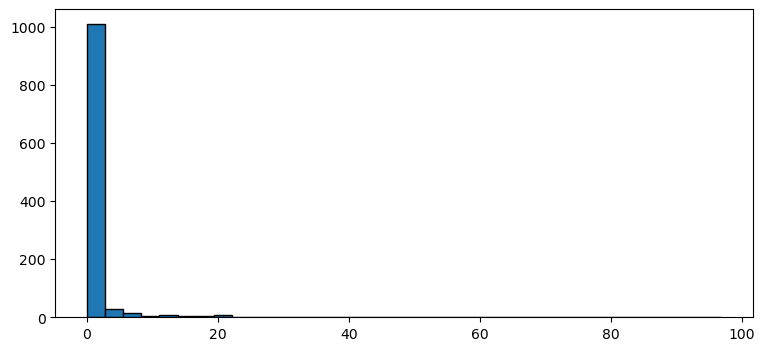

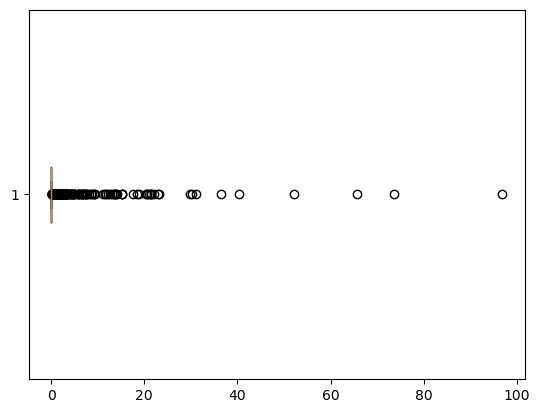

fecha
1      32.3
2      52.1
3      98.9
4      34.6
5      49.4
6      86.1
7      75.5
8      24.0
9     368.8
10    262.1
11     37.4
12    137.7
Name: prec, dtype: float64


,fecha,prec,sol
62,2025-09-29,96.8,0.0
63,2023-09-02,73.5,4.5
64,2025-10-11,65.6,1.0
65,2025-10-10,52.2,0.4
66,2025-12-16,40.4,0.0
67,2023-07-03,36.5,7.6
68,2025-03-18,31.2,0.0
69,2023-02-08,30.2,0.0
70,2025-10-09,29.8,1.4
71,2025-12-28,23.2,1.5


In [7]:
print(df["prec"].describe(percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

ceros_prec = (df["prec"] == 0).sum()
print("Número de días sin precipitación:", ceros_prec)

dias_lluvia = (df["prec"] > 0).sum()
print("Número de días con precipitación:", dias_lluvia)

bins = [-0.01, 0, 5, 10, 20, 50, 100]
labels = ["0 mm", "0-5 mm", "5-10 mm", "10-20 mm", "20-50 mm", "50-100 mm"]
df["prec_intervalo"] = pd.cut(df["prec"], bins=bins, labels=labels)
print(df["prec_intervalo"].value_counts().sort_index())

plt.figure(figsize = (9,4))
plt.hist(df["prec"], bins = 35, edgecolor = "black")
plt.show()

plt.boxplot(df["prec"], vert = False)
plt.show()

print(df.groupby(df["fecha"].dt.month)["prec"].sum())

df.sort_values("prec", ascending=False)[["fecha","prec", "sol"]].head(10)

RELACION ENTRE VARIABLES - MATRIZ DE RELACIONES

In [8]:
vars_clima = ["tmed", "tmin", "tmax", "prec", "sol"]

corr = df[vars_clima].corr()
print(corr)

          tmed      tmin      tmax      prec       sol
tmed  1.000000  0.973546  0.968592 -0.024024  0.422684
tmin  0.973546  1.000000  0.886218  0.036192  0.302198
tmax  0.968592  0.886218  1.000000 -0.087928  0.528555
prec -0.024024  0.036192 -0.087928  1.000000 -0.273010
sol   0.422684  0.302198  0.528555 -0.273010  1.000000


SOL Y TMAX

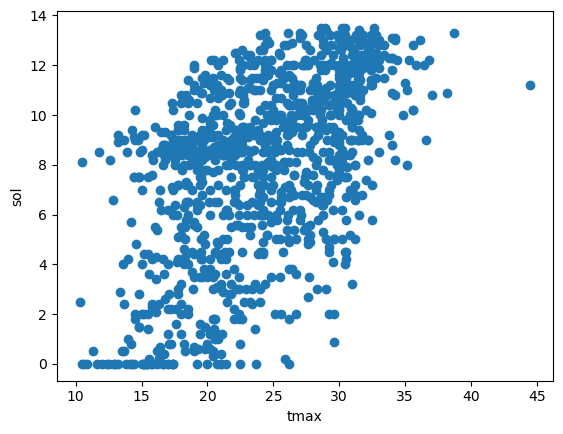

In [9]:
plt.scatter(df["tmax"], df["sol"])
plt.xlabel("tmax")
plt.ylabel("sol")
plt.show()

PRECIPITACION  > 0 Y SOL

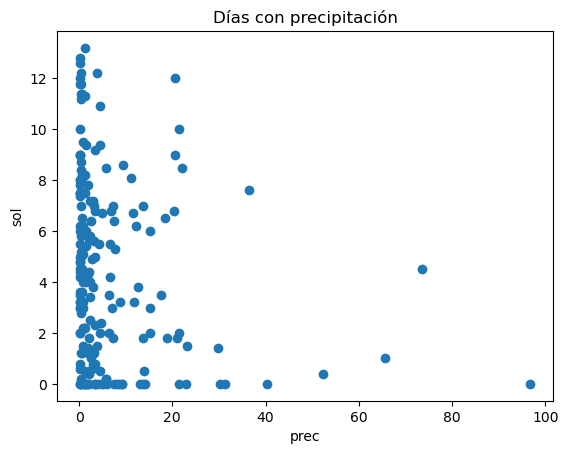

In [10]:
tmp = df[df["prec"] > 0]

plt.scatter(tmp["prec"], tmp["sol"])
plt.xlabel("prec")
plt.ylabel("sol")
plt.title("Días con precipitación")
plt.show()

EVOLUCIÓN DE PRECIPITACIÓN

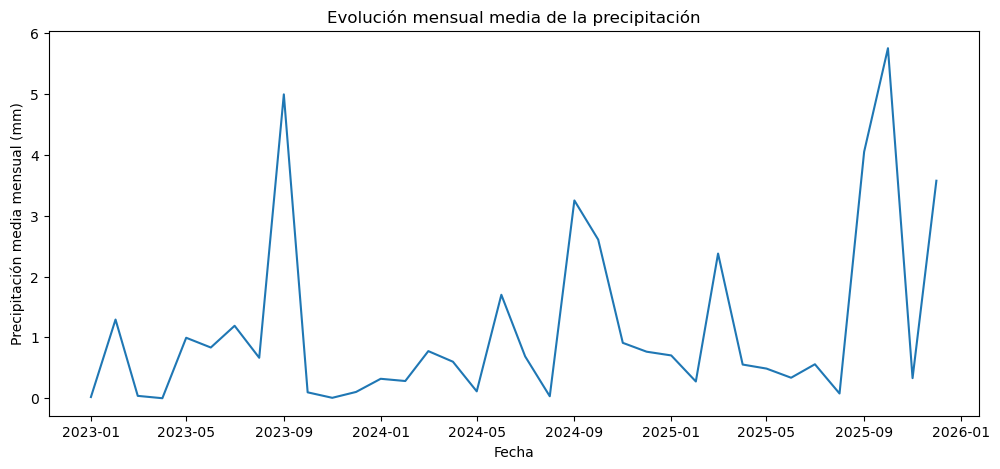

In [11]:
df["año"] = df["fecha"].dt.year

media_mensual = (
    df.groupby(["año", "mes"])[["prec", "sol"]]
      .mean()
      .reset_index()
)

media_mensual["fecha_mes"] = pd.to_datetime(
    media_mensual["año"].astype(str) + "-" + media_mensual["mes"].astype(str) + "-01"
)

# línea de precipitación media mensual
plt.figure(figsize=(12, 5))
plt.plot(media_mensual["fecha_mes"], media_mensual["prec"])
plt.xlabel("Fecha")
plt.ylabel("Precipitación media mensual (mm)")
plt.title("Evolución mensual media de la precipitación")
plt.show()

EVOLUCIÓN SOL

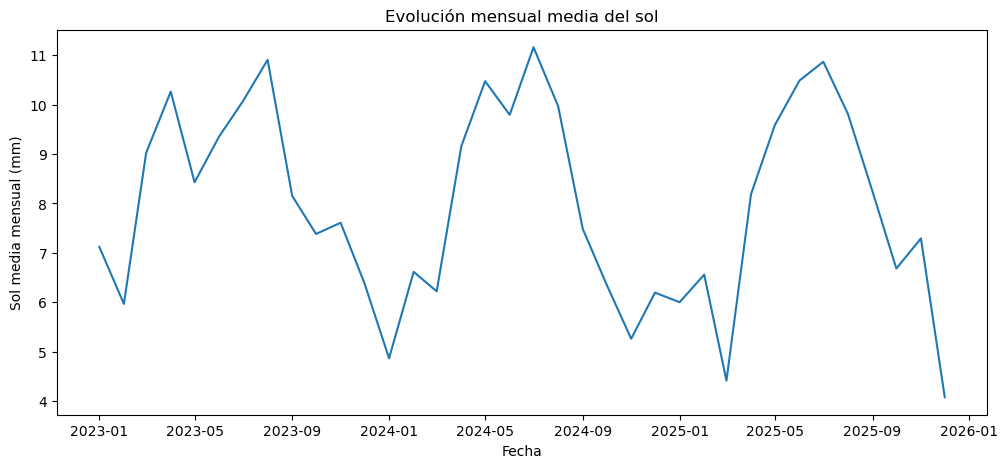

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(media_mensual["fecha_mes"], media_mensual["sol"])
plt.xlabel("Fecha")
plt.ylabel("Sol media mensual (mm)")
plt.title("Evolución mensual media del sol")
plt.show()